# Evaluation

### Reference-free evaluation

### RAGAS

RAGAS provides reference-free, LLM-based evaluation for RAG systems.

In [20]:
from datasets import Dataset

dataset = Dataset.from_dict({
    "question": [
        "What is Retrieval Augmented Generation?"
    ],
    "answer": [
        "RAG combines retrieval with generation to produce grounded responses."
    ],
    "contexts": [[
        "Retrieval Augmented Generation retrieves documents and uses them as context.",
        "RAG improves factual accuracy by grounding responses in external knowledge."
    ]],
    "reference": [
        "Retrieval Augmented Generation is a technique where a language model retrieves relevant documents and uses them to generate grounded responses."
    ]
})

# "RAG combines retrieval with generation to produce grounded responses.",


In [16]:
from langchain.embeddings import HuggingFaceEmbeddings

# Embedding model for RAGAS (semantic similarity)
embeddings = HuggingFaceEmbeddings(
    model_name="thenlper/gte-small",
    model_kwargs={"device": "mps"},  # change to "cuda" if available
    encode_kwargs={"normalize_embeddings": True}
)

/var/folders/yv/kny11ztx72q6t7lv7fh0rg8h0000gn/T/ipykernel_70399/1559105537.py:4: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [17]:
from langchain.llms import LlamaCpp
from ragas.llms import LangchainLLMWrapper

llm_cpp = LlamaCpp(
    model_path="/Users/manojkumar_rajendran/Phi-3-mini-4k-instruct-fp16.gguf",
    n_gpu_layers=-1,
    max_tokens=500,
    n_ctx=4096,
    seed=42,
    temperature=0.1,
    verbose=False,
)

# Wrap LlamaCpp for RAGAS
llm = LangchainLLMWrapper(llm_cpp)

llama_context: n_batch is less than GGML_KQ_MASK_PAD - increasing to 64
ggml_metal_init: skipping kernel_get_rows_bf16                     (not supported)
ggml_metal_init: skipping kernel_set_rows_bf16                     (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32                   (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_c4                (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_1row              (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_l4                (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_bf16                  (not supported)
ggml_metal_init: skipping kernel_mul_mv_id_bf16_f32                (not supported)
ggml_metal_init: skipping kernel_mul_mm_bf16_f32                   (not supported)
ggml_metal_init: skipping kernel_mul_mm_id_bf16_f16                (not supported)
ggml_metal_init: skipping kernel_flash_attn_ext_bf16_h64           (not supported)
ggml_metal_init

In [18]:
print("Embeddings:", embeddings)
print("LLM Judge:", llm)

Embeddings: client=SentenceTransformer(
  (0): Transformer({'max_seq_length': 512, 'do_lower_case': False}) with Transformer model: BertModel 
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
) model_name='thenlper/gte-small' cache_folder=None model_kwargs={'device': 'mps'} encode_kwargs={'normalize_embeddings': True} multi_process=False show_progress=False
LLM Judge: LangchainLLMWrapper(langchain_llm=LlamaCpp(...))


In [21]:
from ragas import evaluate
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall
)

evaluate(
    dataset,
    metrics=[answer_relevancy],
    embeddings=embeddings,
    llm=llm,
)

/var/folders/yv/kny11ztx72q6t7lv7fh0rg8h0000gn/T/ipykernel_70399/3973377821.py:2: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
/var/folders/yv/kny11ztx72q6t7lv7fh0rg8h0000gn/T/ipykernel_70399/3973377821.py:2: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import (
/var/folders/yv/kny11ztx72q6t7lv7fh0rg8h0000gn/T/ipykernel_70399/3973377821.py:2: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import (
/

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

{'answer_relevancy': 0.8984}

### What does each metric represent ?

1) Faithfulness (grounding / hallucination vs context) (Reference-free)

Goal: Is the answer supported by the retrieved contexts?

Typical pipeline:

1.	Use an LLM to break the answer into atomic statements/claims

2.	Use an LLM to check whether each claim is supported by the provided contexts

Data required: question, answer, contexts

Needs LLM: yes

Needs embeddings: sometimes (depends on implementation; many checks are LLM-based)

Important takeaway : Multiple LLM calls are required for one response validation. This is very time consuming

2) Answer relevancy (Reference-free metric)

Goal: Does the answer address the question?

Often implemented as LLM judging relevance (and sometimes embeddings similarity).

Data required: question, answer

Needs LLM: usually yes

3) Context precision (Reference based)

Goal: Are the retrieved contexts useful (few irrelevant chunks)?

In the newer definition, it evaluates usefulness by comparing retrieved contexts against a reference answer.  ￼

So it typically:

checks each retrieved chunk: “Does this chunk help answer the question (relative to reference)?”

precision = relevant_chunks / retrieved_chunks

Data required: question, contexts, reference/ground_truth

4) Context recall (Reference based)

Goal: Did retrieval include all necessary information?

Usually compares what the reference contains vs what the retrieved contexts cover

Data required: question, contexts, reference/ground_truth

### DeepEval

DeepEval is a test-framework–style evaluation library for LLM systems, designed to run fast, deterministically, and at scale, with both LLM-based and non-LLM metrics.

Think of it as pytest for LLMs.

RAGAS explains failures. DeepEval fails builds

In [22]:
from deepeval.models import DeepEvalBaseLLM
from deepeval.test_case import LLMTestCase
from deepeval.metrics import GEval, AnswerRelevancyMetric
from deepeval import evaluate

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [24]:
from deepeval.models import DeepEvalBaseLLM
from llama_cpp import Llama


class LocalQwenJudge(DeepEvalBaseLLM):
    def __init__(
        self,
        model_path: str,
        n_ctx: int = 8192,
        n_gpu_layers: int = -1,
        n_threads: int = 8,
        temperature: float = 0.0,
        verbose: bool = False,
    ):
        # Qwen 2.5 via llama_cpp
        self._model = Llama(
            model_path=model_path,
            n_ctx=n_ctx,
            n_gpu_layers=n_gpu_layers,
            n_threads=n_threads,
            temperature=temperature,
            verbose=verbose,
        )

    def load_model(self):
        # Required by DeepEvalBaseLLM
        return self._model

    def get_model_name(self) -> str:
        return "qwen2.5-7b-local-judge"

    def generate(self, prompt: str) -> str:
        """
        GEval expects plain text output.
        llama_cpp returns a dict → extract text.
        """
        response = self._model(
            prompt,
            max_tokens=256,   # judges don't need long outputs
            stop=None,
        )
        return response["choices"][0]["text"].strip()

    async def a_generate(self, prompt: str) -> str:
        # Async wrapper (DeepEval compatibility)
        return self.generate(prompt)

In [25]:
judge = LocalQwenJudge(
    model_path="/Users/manojkumar_rajendran/qwen2.5-7b-instruct-q5_0-00001-of-00002.gguf",
    n_ctx=8192,          # Qwen benefits from larger context
    n_gpu_layers=-1,     # set to 0 if you see GPU instability
    n_threads=8,         # leverage CPU parallelism
    temperature=0.0,     # deterministic judge behavior
    verbose=False,
)

llama_context: n_ctx_per_seq (8192) < n_ctx_train (131072) -- the full capacity of the model will not be utilized
ggml_metal_init: skipping kernel_get_rows_bf16                     (not supported)
ggml_metal_init: skipping kernel_set_rows_bf16                     (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32                   (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_c4                (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_1row              (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_l4                (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_bf16                  (not supported)
ggml_metal_init: skipping kernel_mul_mv_id_bf16_f32                (not supported)
ggml_metal_init: skipping kernel_mul_mm_bf16_f32                   (not supported)
ggml_metal_init: skipping kernel_mul_mm_id_bf16_f16                (not supported)
ggml_metal_init: skipping kernel_flash_attn_ext_bf16_h64

In [ ]:
metric = AnswerRelevancyMetric(
    threshold=0.7,
    model="gpt-4o-mini",   # or gpt-4.1 / gemini-1.5-pro
    include_reason=True
)

In [ ]:
evaluate(
    test_cases=[tc],
    metrics=[metric]
)

print("Score:", metric.score)
print("Reason:", metric.reason)

Score: 0.94

Reason: The answer directly addresses the question and correctly explains RAG.

In [41]:
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)

df = pd.read_csv("images/deepeval_metrics_catalog.csv")

df.style.set_properties(**{
    "white-space": "pre-wrap",
    "text-align": "left"
})

,Metric,Category,What_it_Measures,When_to_Use,Required_Inputs
0,AnswerRelevancyMetric,Answer Quality,Whether the answer addresses the user question,Detect off-topic or generic answers,"input, actual_output"
1,CorrectnessMetric,Answer Quality,Factual and logical correctness vs reference,When ground truth exists,"input, actual_output, expected_output"
2,CompletenessMetric,Answer Quality,Coverage of all required aspects,Multi-part questions,"input, actual_output, expected_output"
3,ClarityMetric,Answer Quality,Readability and understandability,User-facing assistants,actual_output
4,ConcisenessMetric,Answer Quality,Appropriate brevity without loss,"Chatbots, summaries",actual_output
5,GEval,Custom / General,Rubric-based custom evaluation,"Flexible, reference-free evaluation","input, actual_output, expected_output (any subset)"
6,FaithfulnessMetric,RAG,Claims supported by retrieved context,Hallucination control,"actual_output, retrieval_context"
7,ContextRelevancyMetric,RAG,Relevance of retrieved context,Retrieval quality checks,"input, retrieval_context"
8,ContextPrecisionMetric,RAG,Usefulness of retrieved context,Over-retrieval analysis,"input, retrieval_context"
9,ContextRecallMetric,RAG,Whether all required info was retrieved,Recall-focused tuning,"input, retrieval_context, expected_output"


# MultiModal LLMs

<img src="./images/genai_107.png" width=1000 />

<img src="./images/genai_108.png" width=1000 />

<img src="./images/genai_109.png" width=1000 />

<img src="./images/genai_111.png" width=1000 />

### CLIP (Contrastive Language Image Pre-training)

<img src="./images/genai_112.png" width=1000 />

Zero-shot classification

Clustering

Search

Generation

#### How CLIP is trained

Step - 1 : Embed both text and image using the respective encoder

<img src="./images/genai_110.png" width=1000 />

Step - 2 : Compute the similarity between two embeddings using cosine similarity

<img src="./images/genai_113.png" width=1000 />

Step - 3 : The encoder models are updated with the learning from step 2. Embeddings generated after this step will be more contextual.

<img src="./images/genai_114.png" width=1000 />

Step - 4 : To make sure representations are as accurate as possible, negative samples are also provided during training.

### Code demo

In [26]:
from urllib.request import urlopen
from PIL import Image

# Load an AI-generated image of a puppy playing in the snow
puppy_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/puppy.png"
image = Image.open(urlopen(puppy_path)).convert("RGB")

image.show()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [27]:
image.size

(512, 512)

In [28]:
import numpy as np
image_np = np.array(image)
print(image_np.shape)

(512, 512, 3)


In [51]:
caption = "a puppy playing in the snow"

In [29]:
from transformers import CLIPTokenizerFast, CLIPProcessor, CLIPModel

In [30]:
model_id = "openai/clip-vit-base-patch32"

In [ ]:
# Load a tokenizer to preprocess the text
clip_tokenizer = CLIPTokenizerFast.from_pretrained(model_id)

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

In [46]:
# Load a processor to preprocess the images
clip_processor = CLIPProcessor.from_pretrained(model_id)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

In [47]:
# Main model for generating text and image embeddings
model = CLIPModel.from_pretrained(model_id)

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

In [52]:
# Tokenize the caption

inputs = clip_tokenizer(caption, return_tensors="pt")

In [53]:
inputs

{'input_ids': tensor([[49406,   320,  6829,  1629,   530,   518,  2583, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}

In [54]:
clip_tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

['<|startoftext|>',
 'a</w>',
 'puppy</w>',
 'playing</w>',
 'in</w>',
 'the</w>',
 'snow</w>',
 '<|endoftext|>']

In [55]:
# Create a text embedding

text_embedding = model.get_text_features(**inputs)
text_embedding.shape

torch.Size([1, 512])

In [56]:
# Preprocess image

processed_image = clip_processor(
    text=None, 
    images=image, 
    return_tensors="pt"
)["pixel_values"]

In [57]:
processed_image.shape

torch.Size([1, 3, 224, 224])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7922626..2.145897].


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

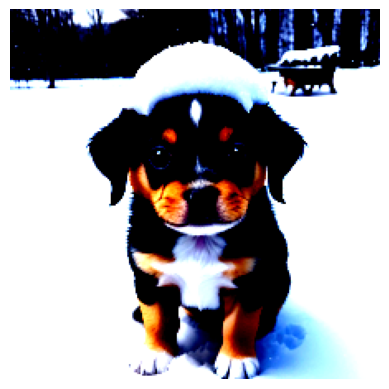

In [61]:
import torch
import numpy as np
import matplotlib.pyplot as plt
# Prepare image for visualization
img = processed_image.squeeze(0)
img = img.permute(*torch.arange(img.ndim - 1,-1,-1))
img = np.einsum("ijk->jik", img)

# Visualize preprocessed image
plt.imshow(img)
plt.axis("off")

In [62]:
# Create the image embedding
image_embedding = model.get_image_features(processed_image)
image_embedding.shape

torch.Size([1, 512])

In [63]:
# Normalize the embeddings
text_embedding /= text_embedding.norm(dim=-1, keepdim=True)
image_embedding /= image_embedding.norm(dim=-1, keepdim=True)

# Calculate their similarity
text_embedding = text_embedding.detach().cpu().numpy()
image_embedding = image_embedding.detach().cpu().numpy()

score = np.dot(text_embedding, image_embedding.T)
score

array([[0.33149633]], dtype=float32)

<img src="./images/genai_115.png" width=1000 />

### Making Text Generation Models Multimodal

<img src="./images/genai_116.png" width=1000 />

### BLIP-2: Bootstrapping Language-Image Pre-training for Unified Vision-Language Understanding and Generation 2

Creating a multimodal language model from scratch requires significant
computing power and data. We would have to use billions of images, text,
and image-text pairs to create such a model. As you can imagine, this is not
easily feasible!

Instead of building the architecture from scratch, BLIP-2 bridges the vision-
language gap by building a bridge, named the Querying Transformer (Q-
Former), that connects a pretrained image encoder and a pretrained LLM

<img src="./images/genai_117.png" width=1000 />

### How BLIP-2 was trained

<img src="./images/genai_118.png" width=1000 />

<img src="./images/genai_119.png" width=1000 />

<img src="./images/genai_120.png" width=1000 />

### Code demo

In [66]:
from transformers import AutoProcessor, Blip2ForConditionalGeneration
import torch
# Load processor and main model
blip_processor = AutoProcessor.from_pretrained("Salesforce/blip2-opt-2.7b")
model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16
)
# Send the model to GPU to speed up inference
device = "cuda" if torch.cuda.is_available() else "mps"
model.to(device)

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/10.0G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

RuntimeError: MPS backend out of memory (MPS allocated: 0 bytes, other allocations: 30.84 GB, max allowed: 30.19 GB). Tried to allocate 1.58 MB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).

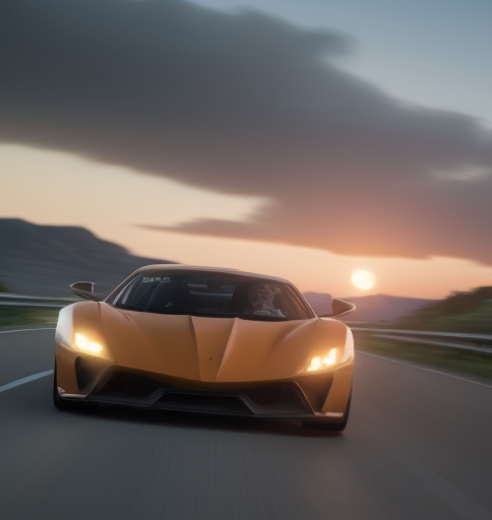

In [2]:
# Load image of a supercar
from urllib.request import urlopen
from PIL import Image
car_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/car.png"
image = Image.open(urlopen(car_path)).convert("RGB")
image

In [5]:
from transformers import AutoProcessor, Blip2ForConditionalGeneration

blip_processor = AutoProcessor.from_pretrained("Salesforce/blip2-opt-2.7b")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [8]:
import torch
inputs = blip_processor(image, return_tensors="pt").to('mps',torch.float16)
inputs["pixel_values"].shape

torch.Size([1, 3, 224, 224])

In [9]:
blip_processor.tokenizer

GPT2TokenizerFast(name_or_path='Salesforce/blip2-opt-2.7b', vocab_size=50265, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '</s>', 'eos_token': '</s>', 'unk_token': '</s>', 'pad_token': '<pad>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	50265: AddedToken("<image>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [ ]:
text = "Her vocalization was remarkably melodic"
token_ids = blip_processor(image, text=text, return_tensors="pt")
token_ids = token_ids.to('mps', torch.float16)["input_ids"][0]

# Convert input ids back to tokens
tokens = blip_processor.tokenizer.convert_ids_to_tokens(token_ids)
tokens

['<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '</s>',
 'Her',
 'Ġvocal',
 'ization',
 'Ġwas',
 'Ġremarkably',
 'Ġmel',
 'odic']

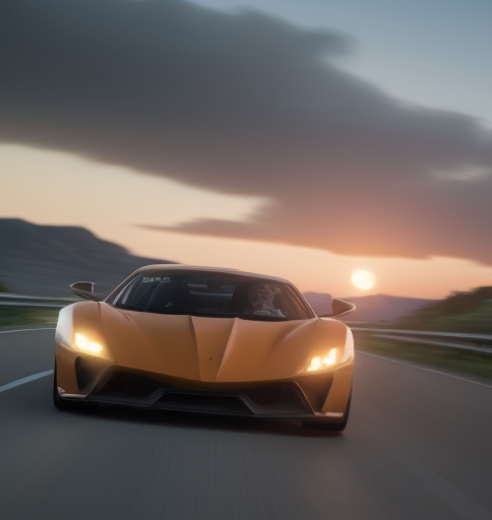

In [14]:
# Load an AI-generated image of a supercar
image = Image.open(urlopen(car_path)).convert("RGB")

# Convert an image into inputs and preprocess it
inputs = blip_processor(image, return_tensors="pt").to('mps',torch.float16)
image

In [ ]:
# Generate image ids to be passed to the decoder (LLM)
generated_ids = model.generate(**inputs, max_new_tokens=20)

# Generate text from the image ids
generated_text = blip_processor.batch_decode(
    generated_ids, 
    skip_special_tokens=True
)

generated_text = generated_text[0].strip()
generated_text

an orange supercar driving on the road at sunset

<img src="./images/genai_121.png" width=1000 />

# Fine-tuning

Domain specialization

    Fine-tuning adapts a general LLM to a specific domain (e.g., fine-tuning BERT on clinical notes for medical entity extraction).

Improved task accuracy

    Task-specific fine-tuning significantly boosts performance over zero-shot prompting (e.g., sentiment classification fine-tuned on customer reviews).

Better language style & tone control

    Models can learn formal, legal, conversational, or brand-specific tone (e.g., fine-tuning for customer support responses).

Handling proprietary or private data

    Enables learning from internal data that cannot be exposed via prompting alone (e.g., enterprise SOPs, internal tickets).

Consistent behavior & reduced variance

    Fine-tuned models respond more deterministically than prompt-only approaches (e.g., structured JSON output generation).

Lower inference cost vs large models

    A fine-tuned smaller model can replace a larger foundation model (e.g., fine-tuned Phi/Mistral instead of GPT-4).

Improved reasoning for narrow tasks

    Models learn recurring reasoning patterns (e.g., invoice validation rules, eligibility checks).

Custom label prediction

    Enables classification into organization-specific labels (e.g., “high-risk / medium-risk / low-risk” claims).

Information extraction at scale

    Fine-tuned BERT excels at NER, key-value extraction, and span detection (e.g., contract clause extraction).

Search & retrieval relevance tuning

    Fine-tuned bi-encoders improve semantic search quality (e.g., job–resume matching).

Alignment with business policies

    Model learns company-specific rules and constraints (e.g., compliance-aware responses in pharma or finance).

Reduced prompt engineering complexity

    Shifts complexity from prompts to model weights (e.g., simpler prompts after instruction fine-tuning).

Multilingual or code-switch adaptation

    Fine-tuning improves performance on specific language mixes (e.g., Hinglish customer chats).

Structured generation & format control

    Models can reliably generate schemas, SQL, or API calls (e.g., SQL generation fine-tuned on enterprise schemas).

Continual learning & versioning

    Enables incremental improvement as new data arrives (e.g., retraining quarterly with new tickets).

Edge / on-device intelligence

    Fine-tuned small models enable local inference (e.g., mobile or laptop-based assistants).

<img src="./images/genai_122.png" width=1000 />

<img src="./images/genai_123.png" width=1000 />

<img src="./images/genai_124.png" width=1000 />

<img src="./images/genai_125.png" width=1000 />

<img src="./images/genai_126.png" width=1000 />

<img src="./images/genai_127.png" width=1000 />

<img src="./images/genai_128.png" width=1000 />